In [1]:
__license__   = "GNU Affero General Public License Version 3 (AGPL-3.0)"
__url__       = "https://github.com/ricrei/energycell_lv_level"
__author__    = "Ricardo Reibsch"

# Minimum working example Energycell LV

This is a minimum working example trying to explain the basic functionalities when using Energycell LV

In [2]:
import os
import csv
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandapower.plotting.plotly as ppply
import seaborn as sns
from datetime import datetime, timedelta

#import tools.evaluation.Evaluation as evaluation

# Handle date time conversions between pandas and matplotlib
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

import tools.tools as tt

import bz2
import _pickle as cPickle

### Define Input Parameters

In [3]:
# define net_name
net_name = ["kerber_rural_1", #0
            "kerber_rural_2", #1
            "kerber_rural_3", #2
            "kerber_rural_4",  #3
            "kerber_village",  #4
            "kerber_suburb_1", #5
            "kerber_suburb_2",  #6
            "simbench_rural_1", #7
            "simbench_rural_2", #8
            "simbench_rural_3", #9
            "simbench_suburb_4", #10
            "simbench_suburb_5", #11
            "simbench_urban_6",  #12
            "test_net_one_load_branch"]  #13

save_fig_dir = 'img/'
output_df_dir = 'output-files/'

n = 2    # Number of timescopes
m = 2*4  # Number of timescopes * Number of scenarios

In [4]:
eva = tt.decompress_pickle(output_df_dir + 'evaluation_dict.pbz2')
df_eva_v = tt.decompress_pickle(output_df_dir + 'evaluation_df_v.pbz2')
df_eva_l = tt.decompress_pickle(output_df_dir + 'evaluation_df_l.pbz2')
df_eva_t = tt.decompress_pickle(output_df_dir + 'evaluation_df_t.pbz2')

In [214]:
# together with plot_curtail_power()
def plot_clustered_stacked(dfall, labels1=None, labels2=None, title=" ",  H=".", **kwargs):
    """Given a list of dataframes, with identical columns and index, create a clustered stacked bar plot. 
labels is a list of the names of the dataframe, used for the legend
title is a string for the title of the plot
H is the hatch used for identification of the different dataframe"""

    n_df = len(dfall)
    n_col = len(dfall[0].columns) 
    n_ind = len(dfall[0].index)
    plt.figure(figsize=(14, 6)) 
    axe = plt.subplot(111)
    #color_map = plt.cm.Spectral_r

    for df in dfall : # for each data frame
        axe = df.plot(kind="bar",
                      linewidth=0,
                      stacked=True,
                      ax=axe,
                      legend=False,
                      grid=False,
                      cmap='summer',
                      **kwargs)  # make bar plots
    
    h,l = axe.get_legend_handles_labels() # get the handles we want to modify
    for i in range(0, n_df * n_col, n_col): # len(h) = n_col * n_df
        for j, pa in enumerate(h[i:i+n_col]):
            for rect in pa.patches: # for each index
                rect.set_x(rect.get_x() + 1 / float(n_df + 1) * i / float(n_col))
                rect.set_hatch(H* int(3*i / n_col))#(H * int(2*i / n_col)) #edited part     
                rect.set_width(1 / float(n_df + 1))
                rect.set_alpha(.9)
                rect.set_aa(True)

                axe.set_xticks((np.arange(0, 2 * n_ind, 2) + .5 / float(n_df + 1)) / 2.)
    axe.set_xticklabels(df.index, rotation = 0)
    axe.set_title(title)

    # Add invisible data to add another legend
    n=[]        
    for i in range(n_df):
        n.append(axe.bar(0, 0, color="lightgrey", hatch=H * 2*i))
    
    if labels1 is not None:
        l1 = axe.legend(h[:n_col], labels1, loc=[.01, .82])#(h[:n_col], l[:n_col], loc=[1.01, 0.5])
    if labels2 is not None:
        l2 = plt.legend(n, labels2, loc=[.01, .7]) 
    axe.add_artist(l1)
    axe.set_xlabel('Grid')
    axe.set_ylabel('Energy in MWh')
    axe.set_xticklabels(['rural 1', 'rural 2', 'rural 3', 'suburban 1', 'suburban 2'])
    axe.set_ylim([0, 120])
    return axe


def plot_curtailed_power(eva, save_fig_dir=None):

  df = pd.DataFrame(columns=['gridID', 'time_scope', 'curtailed_power_pv', 'feed-in_power_pv', 'self-consumed_power_pv', 'curtailed_power_load', 'grid_obtained_power_load', 'self-consumed_power_load'], index=range(10))
  
  scale_factor_energy = 1/60

  i = 0
  for index in eva:
    if eva[index]['scenario'] == 41:
      df['gridID'].iloc[i] = eva[index]['net_name']
      df['time_scope'].iloc[i] = eva[index]['time_scope_name']
      curtailed_power = eva[index]['curtailed_power'].sum()
      df['feed-in_power_pv'].iloc[i] = eva[index]['power']['pv'].sum()*(100-eva[index]['PVConsumption'])/100*scale_factor_energy
      df['self-consumed_power_pv'].iloc[i] = eva[index]['power']['pv'].sum()*(eva[index]['PVConsumption'])/100*scale_factor_energy
      df['curtailed_power_pv'].iloc[i] = curtailed_power['curtail_pv']*scale_factor_energy
      df['grid_obtained_power_load'].iloc[i] = (eva[index]['power']['load'].sum() 
                                              +eva[index]['power']['hp'].sum() 
                                              +eva[index]['power']['ev'].sum()
                                              )*(100-eva[index]['SelfSufficiancy'])/100*scale_factor_energy
      df['self-consumed_power_load'].iloc[i] = (eva[index]['power']['load'].sum() 
                                              +eva[index]['power']['hp'].sum() 
                                              +eva[index]['power']['ev'].sum()
                                              )*(eva[index]['SelfSufficiancy'])/100*scale_factor_energy
      df['curtailed_power_load'].iloc[i] = curtailed_power['curtail_load']*scale_factor_energy  
      i += 1
      
  df_summer = df[df['time_scope'] == 'summer']
  df_winter = df[df['time_scope'] == 'winter']

  df_summer = df_summer.set_index('gridID')
  df_winter = df_winter.set_index('gridID')

  df_summer = df_summer.drop('time_scope', axis=1)
  df_winter = df_winter.drop('time_scope', axis=1)

  df_summer_pv = df_summer
  df_winter_pv = df_winter
  df_summer_load = df_summer
  df_winter_load = df_winter

  df_summer_pv = df_summer_pv.drop('curtailed_power_load', axis=1)
  df_summer_pv = df_summer_pv.drop('grid_obtained_power_load', axis=1)
  df_summer_pv = df_summer_pv.drop('self-consumed_power_load', axis=1)

  df_winter_pv = df_winter_pv.drop('curtailed_power_load', axis=1)
  df_winter_pv = df_winter_pv.drop('grid_obtained_power_load', axis=1)
  df_winter_pv = df_winter_pv.drop('self-consumed_power_load', axis=1)

  df_summer_load = df_summer_load.drop('curtailed_power_pv', axis=1)
  df_summer_load = df_summer_load.drop('feed-in_power_pv', axis=1)
  df_summer_load = df_summer_load.drop('self-consumed_power_pv', axis=1)

  df_winter_load = df_winter_load.drop('curtailed_power_pv', axis=1)
  df_winter_load = df_winter_load.drop('feed-in_power_pv', axis=1)
  df_winter_load = df_winter_load.drop('self-consumed_power_pv', axis=1)
  
  plot_clustered_stacked([df_winter_pv, df_summer_pv], ['curtailed','feed-in','self-consumed'], ['winter', 'summer'], title='Photovoltaic Generation')
  plt.show()
  plot_clustered_stacked([df_winter_load, df_summer_load], ['curtailed','grid-obtained','self-consumed'], ['winter', 'summer'], title='Consumption')
  plt.show()

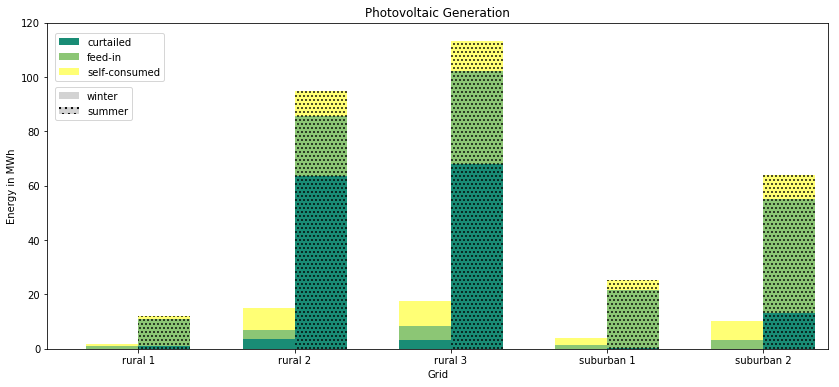

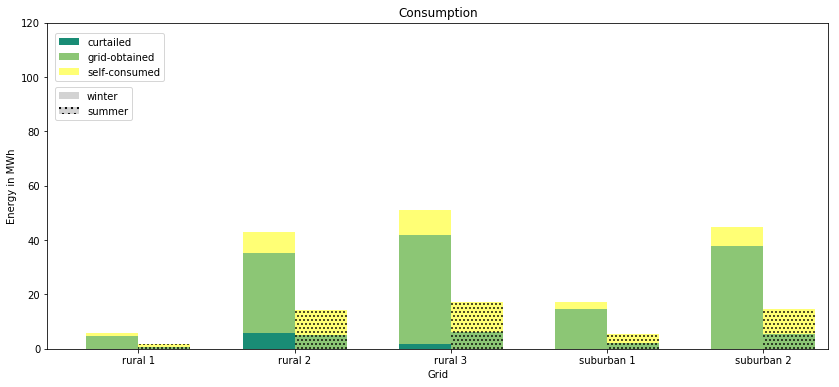

In [215]:
plot_curtailed_power(eva, save_fig_dir=save_fig_dir+'curtailed_power.png')